In [1]:
EXP1 = "G6solar"     # subtrahend  (delta = EXP1 - EXP2)
EXP2 = "G6sulfur"

In [2]:
target_var = "cct"
output_file = "Sorted_CCT_G6solar_and_G6sulfur.nc"

In [3]:
import numpy as np
import xarray as xr
import cftime
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

import xarray as xr
from pathlib import Path

import sys
import os

analysis_path = os.path.abspath("../20260112_Basic_Analysis")
sys.path.append(analysis_path)

import myfunctions as mf

#Package to suppress Python warnings
import warnings
warnings.filterwarnings("ignore")


import xesmf as xe
import xarray as xr
import numpy as np

# =========================
# Base CEDA paths
# =========================

CEDA_BASE = Path("/badc/cmip6/data/CMIP6")


#Model Names
MODELS = {
    # "UKESM1-0-LL":  {"institution": "MOHC",         "ensemble": "r1i1p1f2",  "grid": "gn",},
    # "CNRM-ESM2-1":  {"institution": "CNRM-CERFACS", "ensemble": "r1i1p1f2",  "grid": "gr",}, # CCT Not available for solar
    "MPI-ESM1-2-LR":{"institution": "MPI-M",        "ensemble": "r1i1p1f1",  "grid": "gn",},
    # "CESM2-WACCM":  {"institution": "NCAR",         "ensemble": "r1i1p1f1",  "grid": "gn",},
    "IPSL-CM6A-LR": {"institution": "IPSL",         "ensemble": "r1i1p1f1",  "grid": "gr",},
}


# =========================
# Experiment registry
# =========================

EXP_REGISTRY = {
    "piControl": {"project": "CMIP",        "scenario": "piControl"},
    "HIST":      {"project": "CMIP",        "scenario": "historical"},
    "SSP245":    {"project": "ScenarioMIP", "scenario": "ssp245"},
    "SSP585":    {"project": "ScenarioMIP", "scenario": "ssp585"},
    "G6solar":   {"project": "GeoMIP",      "scenario": "G6solar"},
    "G6sulfur":  {"project": "GeoMIP",      "scenario": "G6sulfur"},
}

# Built automatically from EXP1 and EXP2
EXPERIMENTS = {
    EXP1: EXP_REGISTRY[EXP1],
    EXP2: EXP_REGISTRY[EXP2],
}


In [4]:
# ================================================================
# Utility: year-range label per experiment
# ================================================================

def _exp_year_label(exp_name):
    """Return the year-range suffix for an experiment name."""
    if exp_name in ("G6sulfur", "SSP585", "SSP245"):
        return "20212100"
    elif exp_name == "HIST":
        return "19212000"
    else:
        raise ValueError(f"Unknown experiment '{exp_name}'. "
                         "Add it to _exp_year_label().")

def _time_slice(exp_name):
    """Return the (start, end) time slice strings for an experiment."""
    if exp_name in ("G6sulfur", "SSP585", "SSP245"):
        return ("2021-01-01", "2100-12")   # 80 years
    elif exp_name == "HIST":
        return ("1921-01-01", "2000-12")   # 80 years
    else:
        raise ValueError(f"Unknown experiment '{exp_name}'.")


def roll_lon(da):
    """Roll longitude from 0-360 to -180-180."""
    da = da.assign_coords(lon=(((da.lon + 180) % 360) - 180))
    return da.sortby('lon')


def regrid_to_common(da, target_lat=None, target_lon=None):
    """Regrid a DataArray to common lat/lon grid."""
    if target_lat is None:
        target_lat = np.arange(-50, 51, 2.5)
    elif isinstance(target_lat, tuple):
        target_lat = np.arange(target_lat[0], target_lat[1]+1, 2.5)
    elif isinstance(target_lat, (int, float)):
        target_lat = np.arange(-target_lat, target_lat+1, 2.5)

    if target_lon is None:
        target_lon = np.arange(0, 360, 2.5)  # always default to full lon
    elif isinstance(target_lon, tuple):
        target_lon = np.arange(target_lon[0], target_lon[1]+1, 2.5)

    ds_out = xr.Dataset({
        'lat': (['lat'], target_lat),
        'lon': (['lon'], target_lon)
    })

    # Handle both DataSet and DataArray cases
    if isinstance(da, xr.Dataset):
        ds_in = da
    else:
        ds_in = da.to_dataset(name='data')
        
    regridder = xe.Regridder(ds_in, ds_out, method='bilinear', reuse_weights=False)
    return regridder(da) 
    
def climatology_and_uncertainty(da_year, block_size=30):
    """
    da_year: DataArray with dimension 'year'
    Returns:
        clim_mean  : mean climatology (mean of 30-yr block means)
        clim_sd    : std dev across 30-yr block means
        block_means: DataArray of each 30-yr mean
    """

    n_years = da_year.sizes["year"]
    n_blocks = n_years // block_size

    # Trim excess years
    da_trim = da_year.isel(year=slice(0, n_blocks * block_size))

    # Create block index
    block = xr.DataArray(
        np.repeat(np.arange(n_blocks), block_size),
        dims="year",
        coords={"year": da_trim.year},
        name="block"
    )

    # Compute 30-year means
    block_means = (
        da_trim
        .groupby(block)
        .mean(dim="year")*86400
    )

    # Climatological mean (mean of 30-year means)
    clim_mean = block_means.mean(dim="block")

    # Spread across 30-year climatologies
    clim_sd = block_means.std(dim="block")

    return clim_mean, clim_sd, block_means


def load_model_data(base_path, model_name, scenario, mf):
    """
    Generic loader for model data based on model and scenario.

    Parameters
    ----------
    base_path : str or Path
        File path(s) to load
    model_name : str
    scenario : str
    mf : module
        Your module with open_files functions

    Returns
    -------
    xarray.Dataset
    """
    print(str(base_path))

    if model_name == "CESM2-WACCM":
        if scenario == "G6sulfur":
            return mf.open_files_CESM_G6sulfur(base_path)
        elif scenario == "ssp585":
            return mf.open_files_CESM_ssp585(base_path)
        else:
            return mf.open_files(str(base_path))

    elif model_name == "IPSL-CM6A-LR":
        if scenario == "ssp585":
            return mf.open_files_IPSL_ssp585(base_path)
        else:
            return mf.open_files(str(base_path))

    else:
        return mf.open_files(str(base_path))



def load_model_data_alt_path(base_path, project, institution, model_name, scenario, ensemble, grid, mf, var_name=None):
    """
    Generic loader for model data based on model and scenario.
    
    Parameters
    ----------
    base_path : str or Path
        File path(s) to load
    model_name : str
    scenario : str
    mf : module
        Your module with open_files functions
    var_name : str, optional
        Variable name (e.g., 'ua', 'va') to check for downloaded files
    
    Returns
    -------
    xarray.Dataset
    """
    print(str(base_path))
    
    # Check if files exist at base_path, otherwise look in downloaded directory
    base_path = Path(base_path)
    downloaded_base = Path("/home/users/bidyut/data")
    
    # if not base_path.exists() or not list(base_path.glob("*.nc")):
    if not any(base_path.glob("*.nc")):
        # Try downloaded directory
        if var_name:
            # --- special-case ensemble override ---
            if model_name == "CESM2-WACCM":
                ensemble = "r1i1p1f2" if scenario == "G6sulfur" else "r1i1p1f1"
            alt_path = (downloaded_base / project / institution / model_name / scenario / ensemble / "Amon" / 
                       var_name / grid / "latest")
            print(f"Alt path is: {alt_path}")
            if alt_path.exists():
                print(f"  → Using downloaded files at: {alt_path}")
                base_path = alt_path
    
    if model_name == "CESM2-WACCM":
        if scenario == "G6sulfur":
            return mf.open_files_CESM_G6sulfur(base_path)
        elif scenario == "ssp585":
            return mf.open_files_CESM_ssp585(base_path)
        else:
            return mf.open_files(str(base_path))
    elif model_name == "IPSL-CM6A-LR":
        if scenario == "ssp585":
            return mf.open_files_IPSL_ssp585(base_path)
        else:
            return mf.open_files(str(base_path))
    else:
        return mf.open_files(str(base_path))


def roll_and_regrid(varname):
    return roll_lon(regrid_to_common(varname, target_lat=30))

def roll_and_regrid_3d(ds, target_lat=30):
    """Roll and regrid, handling both 2D and 3D data."""
    ds = roll_lon(ds)
    
    if 'plev' in ds.dims or 'lev' in ds.dims:
        lev_dim = 'plev' if 'plev' in ds.dims else 'lev'
        regridded_levels = []
        for lev_val in ds[lev_dim].values:
            level_data = ds.sel({lev_dim: lev_val})
            regridded = regrid_to_common(level_data, target_lat=target_lat)
            regridded_levels.append(regridded)
        return xr.concat(regridded_levels, dim=lev_dim)
    else:
        return regrid_to_common(ds, target_lat=target_lat)

In [5]:
def sort_profile_1level(ds_wap, ds_var, percentiles=np.arange(0, 101, 1)):
    """
    Sort a 1-level variable by 500 hPa vertical velocity (w500).
    
    For each month (1-12), sorts all spatial points by their w500 value,
    then computes the mean value for each percentile bin.
    
    Parameters
    ----------
    ds_wap : xr.Dataset or xr.DataArray
        Vertical velocity (wap) with dimensions (time, plev, lat, lon)
    ds_var : xr.Dataset or xr.DataArray
        1-level variable (e.g., pr, tas) with dimensions (time, lat, lon)
    percentiles : array-like
        Percentile bins (0–100)
    
    Returns
    -------
    xr.Dataset
        Dataset with dimensions (month, percentile)
    """
    import numpy as np
    import xarray as xr
    
    # Extract variables
    wap = ds_wap['wap'] if isinstance(ds_wap, xr.Dataset) else ds_wap
    if isinstance(ds_var, xr.Dataset):
        var_name = list(ds_var.data_vars)[0]
        var = ds_var[var_name]
    else:
        var = ds_var
        var_name = var.name or 'var'
    
    # Align time

    print("wap unique times:", wap.indexes['time'].is_unique)
    print("var unique times:", var.indexes['time'].is_unique)
    
    common_times = np.intersect1d(wap.time.values, var.time.values)    
    wap = wap.sel(time=common_times)
    var = var.sel(time=common_times)
    print(f"  Aligned to {len(common_times)} common time steps")
    
    # Select 500 hPa
    if 'plev' in wap.dims:
        w500 = wap.sel(plev=50000, method='nearest')
    elif 'lev' in wap.dims:
        w500 = wap.sel(lev=50000, method='nearest')
    else:
        raise ValueError(f"wap must have 'plev' or 'lev' dimension")
    
    # Months
    months = w500.time.dt.month.values
    unique_months = np.arange(1, 13)
    n_months = len(unique_months)
    n_percentiles = len(percentiles)
    
    sorted_var = np.full((n_months, n_percentiles), np.nan)
    w500_percentiles = np.full((n_months, n_percentiles), np.nan)
    counts = np.zeros((n_months, n_percentiles), dtype=int)
    
    print(f"  Sorting 1-level variable '{var_name}' by w500...")
    
    for month_idx, month in enumerate(unique_months):
        month_mask = months == month
        w500_month = w500.isel(time=month_mask)
        var_month = var.isel(time=month_mask)
        
        # Flatten
        w500_flat = w500_month.values.flatten()
        var_flat = var_month.values.flatten()
        
        # Remove NaNs
        valid_mask = ~np.isnan(w500_flat) & ~np.isnan(var_flat)
        w500_valid = w500_flat[valid_mask]
        var_valid = var_flat[valid_mask]
        
        if len(w500_valid) == 0:
            print(f"    Month {month}: No valid data")
            continue
        
        # Sort by w500 (CRITICAL: sort both arrays together)
        sort_indices = np.argsort(w500_valid)
        w500_sorted = w500_valid[sort_indices]
        var_sorted = var_valid[sort_indices]
        
        # Compute percentile bins using indices (not values)
        for p_idx, (p_low, p_high) in enumerate(zip(percentiles[:-1], percentiles[1:])):
            
            # Find indices in this percentile range
            idx_low = int(np.floor(len(w500_sorted) * p_low / 100))
            idx_high = int(np.ceil(len(w500_sorted) * p_high / 100))
            
            if idx_high > idx_low:
                # Average variable in this percentile bin
                sorted_var[month_idx, p_idx] = np.nanmean(var_sorted[idx_low:idx_high])
                w500_percentiles[month_idx, p_idx] = np.nanmean(w500_sorted[idx_low:idx_high])
                counts[month_idx, p_idx] = idx_high - idx_low
        
        # Handle 100th percentile separately (last value)
        sorted_var[month_idx, -1] = var_sorted[-1]
        w500_percentiles[month_idx, -1] = w500_sorted[-1]
        counts[month_idx, -1] = 1
        
        print(f"    Month {month:2d}: Sorted {len(w500_valid):6d} points")
    
    # Output dataset
    ds_out = xr.Dataset(
        {
            'sorted_var': (['month', 'percentile'], sorted_var),
            'w500_percentile': (['month', 'percentile'], w500_percentiles),
            'count': (['month', 'percentile'], counts),
        },
        coords={
            'month': unique_months,
            'percentile': percentiles,
        },
        attrs={
            'description': '1-level variable sorted by w500',
            'variable': var_name,
        }
    )
    
    return ds_out

In [6]:
"""
SORTING SECTION
"""


import os

# output_file = "ConvectiveMassFlux_sorted_G6sulfur_minus_SSP245.nc"
# output_file = "Omega_sorted_G6sulfur_and_SSP245.nc"


if not os.path.exists(output_file):
    print('#'*40)
    print("File does not exist — running code")
    print('#'*40)


    # ================================================================
    # MAIN PROCESSING LOOP
    # ================================================================
    
    all_results = {}
    
    for model_name, model_meta in MODELS.items():
    
        components_by_exp = {}  # Store all components for each experiment
        seasonal_data = {}      # Store seasonal means by year
    
        # ----------------------------
        # 1) LOAD DATA FOR A MODEL : ALL EXPERIMENTS
        # ----------------------------
        for exp, meta in EXPERIMENTS.items():
    
            # --- special-case ensemble override ---
            if model_name == "CESM2-WACCM":
                ensemble = "r1i1p1f2" if meta["scenario"] == "G6sulfur" else "r1i1p1f1"
            else:
                ensemble = model_meta["ensemble"]
    
            def make_base(vname):
                return (
                    CEDA_BASE
                    / meta["project"]
                    / model_meta["institution"]
                    / model_name
                    / meta["scenario"]
                    / ensemble
                    / "Amon"
                    / vname
                    / model_meta["grid"]
                    / "latest"
                )
    

            # target_var = "wap"
            base_wap = make_base("wap")
            base_profile = make_base(target_var)
            
            ####### Handle ALTERNATE base paths ######
            ds_wap = load_model_data_alt_path(base_wap, meta["project"], model_meta["institution"], 
                                              model_name, meta["scenario"], 
                                              ensemble, model_meta["grid"], mf, "wap")
            ds_profile  = load_model_data_alt_path(base_profile, meta["project"], model_meta["institution"], 
                                              model_name, meta["scenario"], 
                                              ensemble, model_meta["grid"], mf, target_var)
            
            # Roll and regrid
            # ds_wap      = roll_and_regrid(ds_wap)          #can I regrid_to_common for Bombardi and Boos boxes?
            # ds_profile  = roll_and_regrid(ds_profile)
            ds_wap = roll_and_regrid_3d(ds_wap, target_lat=30)
            ds_profile = roll_and_regrid_3d(ds_profile, target_lat=30)
            
            print(f"  [{model_name}] {exp}: wap loaded {ds_wap.sizes['time']} months "
                  f"({ds_wap.time.values[0]} → {ds_wap.time.values[-1]})")
            print(f"  [{model_name}] {exp}: {target_var} loaded {ds_profile.sizes['time']} months "
                  f"({ds_profile.time.values[0]} → {ds_profile.time.values[-1]})")

            
            # Calculate sorted profiles
            print(f"  [{model_name}] {exp}: Sorting profiles by w500...")
            sorted_profiles = sort_profile_1level(ds_wap, ds_profile, percentiles=np.arange(0, 101, 1))
            
            # Store for this experiment
            components_by_exp[exp] = sorted_profiles
    
        # After all experiments for this model
        all_results[model_name] = components_by_exp
    
    
    # ================================================================
    # 5) CREATE OUTPUT NETCDF FILE
    # ================================================================
    
    # Stack all models into one dataset
    model_list = []
    for model_name in all_results.keys():
        exp_list = []
        for exp in EXPERIMENTS.keys():
            if exp in all_results[model_name]:
                ds = all_results[model_name][exp]
                ds = ds.expand_dims({'experiment': [exp]})
                exp_list.append(ds)
        
        # Combine experiments for this model
        if exp_list:
            ds_model = xr.concat(exp_list, dim='experiment')
            ds_model = ds_model.expand_dims({'model': [model_name]})
            model_list.append(ds_model)
    
    # Combine all models
    ds_combined = xr.concat(model_list, dim='model')
    
    # Save
    print(f"\nSaving to {output_file}...")
    ds_combined.to_netcdf(output_file)
    print(f"✓ Saved successfully!")
    print(f"  Dimensions: {dict(ds_combined.dims)}")
    print(f"  Variables: {list(ds_combined.data_vars)}")

else:
    print('#'*40)
    print(f"{output_file} already exists — skipping its computation")
    print('#'*40)

########################################
File does not exist — running code
########################################
/badc/cmip6/data/CMIP6/GeoMIP/MPI-M/MPI-ESM1-2-LR/G6solar/r1i1p1f1/Amon/wap/gn/latest
Alt path is: /home/users/bidyut/data/GeoMIP/MPI-M/MPI-ESM1-2-LR/G6solar/r1i1p1f1/Amon/wap/gn/latest
  → Using downloaded files at: /home/users/bidyut/data/GeoMIP/MPI-M/MPI-ESM1-2-LR/G6solar/r1i1p1f1/Amon/wap/gn/latest
/badc/cmip6/data/CMIP6/GeoMIP/MPI-M/MPI-ESM1-2-LR/G6solar/r1i1p1f1/Amon/cct/gn/latest
Alt path is: /home/users/bidyut/data/GeoMIP/MPI-M/MPI-ESM1-2-LR/G6solar/r1i1p1f1/Amon/cct/gn/latest
  → Using downloaded files at: /home/users/bidyut/data/GeoMIP/MPI-M/MPI-ESM1-2-LR/G6solar/r1i1p1f1/Amon/cct/gn/latest
  [MPI-ESM1-2-LR] G6solar: wap loaded 540 months (2035-01-16 12:00:00 → 2099-12-16 12:00:00)
  [MPI-ESM1-2-LR] G6solar: cct loaded 1020 months (2015-01-16 12:00:00 → 2099-12-16 12:00:00)
  [MPI-ESM1-2-LR] G6solar: Sorting profiles by w500...
wap unique times: True
var unique

## Plotting 

In [7]:
def plot_sorted_profiles_comparison(
    ds_sorted,
    exp1='G6sulfur',
    exp2='SSP245',
    months=(6, 9),
    percentile_range=(0, 10),
    variable_name='sorted_var',
    figsize=(10, 4),
    save_fig=False,
    fig_path=None,
    spread=False,
):
    """
    Plot 1-level variable sorted by w500 for two experiments.
    """
    import numpy as np
    import matplotlib.pyplot as plt

    # Select percentile range and months
    if months[0] > months[1]:  # wrapping case
        month_mask = (ds_sorted.month >= months[0]) | (ds_sorted.month <= months[1])
        data = ds_sorted[variable_name].where(month_mask, drop=True).sel(
            percentile=slice(percentile_range[0], percentile_range[1])
        )
    else:
        data = ds_sorted[variable_name].sel(
            percentile=slice(percentile_range[0], percentile_range[1]),
            month=slice(months[0], months[1])
        )

    # Average over percentiles and months
    data = data.mean(dim=['percentile', 'month'])
    # dims now: (model, experiment)

    # Select experiments
    data_exp1 = data.sel(experiment=exp1)
    data_exp2 = data.sel(experiment=exp2)

    # Multi-model mean and spread
    mean_exp1 = data_exp1.mean(dim='model')
    std_exp1  = data_exp1.std(dim='model')

    mean_exp2 = data_exp2.mean(dim='model')
    std_exp2  = data_exp2.std(dim='model')

    # Create plot
    fig, ax = plt.subplots(figsize=figsize)

    y1, y2 = 0.1, -0.1  # vertical offsets for clarity

    # Plot exp1
    ax.plot(mean_exp1, y1, 'o', color='red', label=exp1)
    if spread:
        ax.hlines(
            y=y1,
            xmin=mean_exp1 - std_exp1,
            xmax=mean_exp1 + std_exp1,
            color='red',
            alpha=0.4,
            linewidth=6
        )

    # Plot exp2
    ax.plot(mean_exp2, y2, 'o', color='blue', label=exp2)
    if spread:
        ax.hlines(
            y=y2,
            xmin=mean_exp2 - std_exp2,
            xmax=mean_exp2 + std_exp2,
            color='blue',
            alpha=0.4,
            linewidth=6
        )

    # Formatting
    ax.set_yticks([])
    ax.set_ylabel('')
    ax.set_xlabel(variable_name.replace('_', ' ').title(), fontsize=12)

    ax.grid(True, axis='x', alpha=0.3)
    ax.legend(loc='best', fontsize=11, framealpha=0.9)

    # Title
    month_names = {1: 'Jan', 2: 'Feb', 6: 'Jun', 7: 'Jul', 8: 'Aug', 9: 'Sep', 11: 'Nov', 12: 'Dec'}
    month_str = '-'.join([month_names.get(m, str(m)) for m in range(months[0], months[1] + 1)])

    if percentile_range[1] <= 50:
        circulation = f'Strong Ascent (w500 percentile {percentile_range[0]}–{percentile_range[1]}%)'
    else:
        circulation = f'Strong Descent (w500 percentile {percentile_range[0]}–{percentile_range[1]}%)'

    ax.set_title(
        f'{variable_name.replace("_", " ").title()} | {circulation}\n'
        f'{month_str} | Multi‑Model Mean ± 1 Std Dev',
        fontsize=12,
        fontweight='bold'
    )

    plt.tight_layout()

    if save_fig:
        path = fig_path or f'sorted_{variable_name}_{exp1}_vs_{exp2}_p{percentile_range[0]}-{percentile_range[1]}.png'
        fig.savefig(path, dpi=300, bbox_inches='tight')
        print(f"Figure saved → {path}")

    plt.show()

    return fig, ax


In [8]:
# Load the dataset
ds_sorted = xr.open_dataset(output_file)
# ds_sorted = xr.open_dataset('Omega_sorted_G6sulfur_and_SSP245.nc')

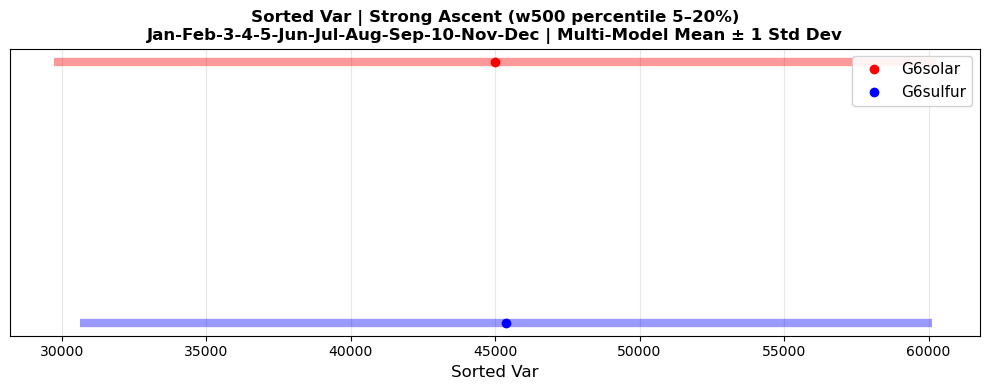

In [9]:
# Strong ascent (lowest 10% of w500, i.e., strongest upward motion)
fig, ax = plot_sorted_profiles_comparison(
    ds_sorted,
    exp1=EXP1,
    exp2=EXP2,
    months=(1, 12),  # JJAS
    percentile_range=(5, 20),  # Strong ascent
    save_fig=False,
    spread=True,
)

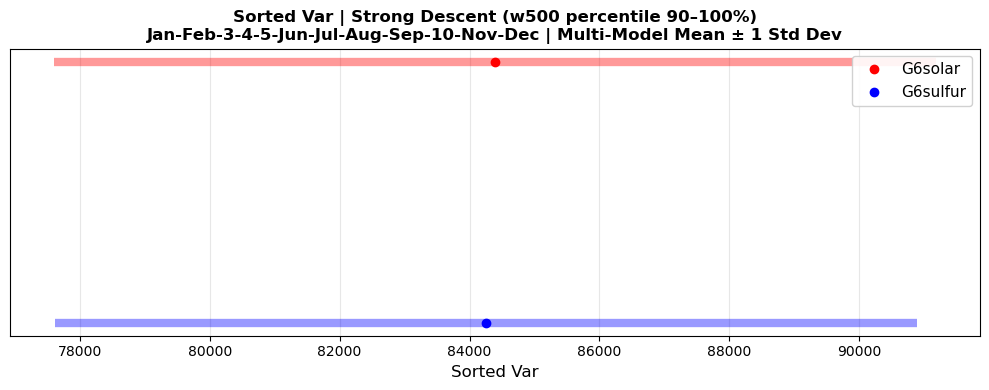

In [10]:
# Strong ascent (highest 10% of w500, i.e., strongest dwownard motion)
fig, ax = plot_sorted_profiles_comparison(
    ds_sorted,
    exp1=EXP1,
    exp2=EXP2,
    months=(1, 12),  # JJAS
    percentile_range=(90, 100),  # Strong ascent
    save_fig=False,
    spread=True,
)

In [11]:
def plot_sorted_percentile_comparison(
    ds_sorted,
    exp1="G6sulfur",
    exp2="SSP245",
    variable_name="sorted_var",
    figsize=(11, 6),
    spread=False,
    save_fig=False,
    fig_path=None,
):
    """
    Plot sorted composites across all percentiles:
    - x-axis: percentile
    - left y-axis: w500 (sorting key)
    - right y-axis: sorted variable
    Annual mean (months 1–12), multi-model mean ± spread.
    """

    import matplotlib.pyplot as plt
    import numpy as np

    # --- Annual mean ---
    w500 = ds_sorted["w500_percentile"].mean(dim="month")
    var  = ds_sorted[variable_name].mean(dim="month")/1000

    # --- Select experiments ---
    w500_1 = w500.sel(experiment=exp1)
    w500_2 = w500.sel(experiment=exp2)

    var_1 = var.sel(experiment=exp1)
    var_2 = var.sel(experiment=exp2)

    # --- Multi-model statistics ---
    w500_1_mean = w500_1.mean(dim="model")
    w500_2_mean = w500_2.mean(dim="model")
    w500_1_std  = w500_1.std(dim="model")
    w500_2_std  = w500_2.std(dim="model")

    var_1_mean = var_1.mean(dim="model")
    var_2_mean = var_2.mean(dim="model")
    var_1_std  = var_1.std(dim="model")
    var_2_std  = var_2.std(dim="model")

    percentiles = ds_sorted.percentile.values

    # --- Plot ---
    fig, ax1 = plt.subplots(figsize=figsize)
    ax2 = ax1.twinx()

    # w500 (left axis)
    ax1.plot(
        percentiles, w500_1_mean,
        color="black", linewidth=2.5, label=f"w500 ({exp1})"
    )
    ax1.plot(
        percentiles, w500_2_mean,
        color="black", linewidth=2.5, linestyle="--", label=f"w500 ({exp2})"
    )

    if spread:
        ax1.fill_between(
            percentiles,
            w500_1_mean - w500_1_std,
            w500_1_mean + w500_1_std,
            color="black", alpha=0.15
        )
        ax1.fill_between(
            percentiles,
            w500_2_mean - w500_2_std,
            w500_2_mean + w500_2_std,
            color="black", alpha=0.10
        )

    # sorted_var (right axis)
    ax2.plot(
        percentiles, var_1_mean,
        color="red", linewidth=2.5, label=f"CCT Pressure ({exp1})"
    )
    ax2.plot(
        percentiles, var_2_mean,
        color="blue", linewidth=2.5, linestyle="--",
        label=f"CCT Pressure ({exp2})"
    )

    if spread:
        ax2.fill_between(
            percentiles,
            var_1_mean - var_1_std,
            var_1_mean + var_1_std,
            color="tab:red", alpha=0.25
        )
        ax2.fill_between(
            percentiles,
            var_2_mean - var_2_std,
            var_2_mean + var_2_std,
            color="tab:blue", alpha=0.25
        )

    # --- Formatting ---
    ax1.axhline(0, color="gray", linestyle="--", linewidth=1, alpha=0.6)
    ax1.set_xlabel("w500 Percentile", fontsize=12)
    ax1.set_ylabel("w500 (Pa s$^{-1}$)", fontsize=12)
    ax2.set_ylabel("Air Pressure at Convective Cloud Top (hPa)", fontsize=12)

    ax1.grid(True, linestyle="--", alpha=0.3)

    # Combined legend
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2,
               loc="best", fontsize=10, framealpha=0.9)

    ax1.set_title(
        f"Circulation‑Sorted Annual Mean Composites\n"
        f"{exp1} vs {exp2} | Multi‑Model Mean"
        + (" ± 1σ" if spread else ""),
        fontsize=13,
        fontweight="bold"
    )

    plt.tight_layout()

    if save_fig:
        path = fig_path or f"sorted_percentiles_{variable_name}_{exp1}_vs_{exp2}.png"
        fig.savefig(path, dpi=300, bbox_inches="tight")
        print(f"Figure saved → {path}")

    plt.show()

    return fig, (ax1, ax2)

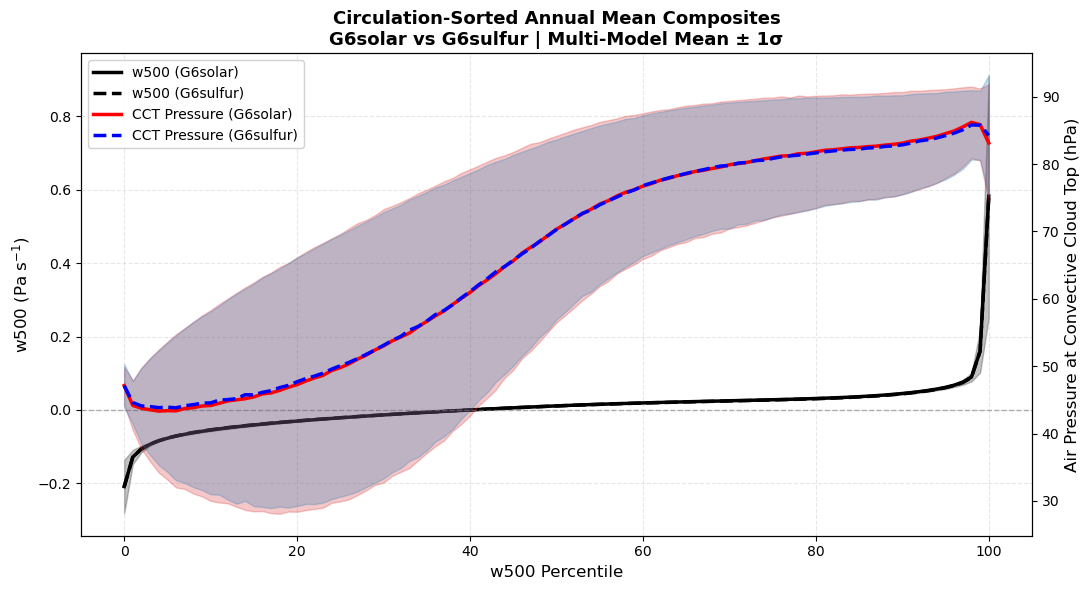

In [12]:
fig, axes = plot_sorted_percentile_comparison(
    ds_sorted,
    exp1=EXP1,
    exp2=EXP2,
    variable_name="sorted_var",
    spread=True
)